# GT Assignment — Part I + Part II
## Synthetic 10,000-Node Network using a Stochastic Kronecker Graph

**Assignment:** To Construct Real Life Network Synthetically of 10000 Nodes and Discover Meaningful Insights & Visualization using NetworkX and Gephi Tools.

**Part I:** Construct synthetic network using a Kronecker graph model.  
**Part II:** NetworkX visualization, network insights, community detection and modularity.

> **Method note:** A standard 2×2 Kronecker expansion produces powers of two. This notebook uses a stochastic Kronecker graph generator and creates exactly 10,000 nodes directly, avoiding the unavailable `networkx.kronecker_graph()` API and avoiding construction of a huge 16,384×16,384 probability matrix.

**Replace `YOUR_PRN_NO` below before submission.**


In [1]:
# Cell 1 — Install packages if required
# Uncomment the next line in Google Colab if packages are missing.

# !pip install -U networkx pandas numpy matplotlib scipy

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
from collections import Counter

print("NetworkX:", nx.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


NetworkX: 3.6.1
NumPy: 2.1.3
Pandas: 2.2.3


In [2]:
# Cell 2 — Configuration

SEED = 42
TARGET_NODES = 10000
PRN_NO = "YOUR_PRN_NO"

OUTPUT_DIR = "GT_Assign_Output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2×2 Kronecker initiator matrix.
# These values control the probability of selecting each pair of bits.
INITIATOR = np.array([
    [0.90, 0.50],
    [0.50, 0.30]
], dtype=float)

# Normalize to a probability distribution for the stochastic generator.
INITIATOR_PROB = INITIATOR / INITIATOR.sum()

print("Target nodes:", TARGET_NODES)
print("Initiator matrix:")
print(INITIATOR)
print("\nNormalized initiator:")
print(INITIATOR_PROB)


Target nodes: 10000
Initiator matrix:
[[0.9 0.5]
 [0.5 0.3]]

Normalized initiator:
[[0.40909091 0.22727273]
 [0.22727273 0.13636364]]


## Part I — Stochastic Kronecker Graph Construction

The generator below samples node IDs bit-by-bit from the initiator matrix. It produces exactly 10,000 nodes without allocating a dense 16,384×16,384 matrix.

The `EDGE_ATTEMPTS_FACTOR` controls sparsity. A value of 3 means approximately `3 × 10,000` edge attempts before duplicate/self-loop removal. Increase it if the resulting graph is too sparse for visualization or community analysis.


In [3]:
# Cell 3 — Efficient stochastic Kronecker graph generator

def stochastic_kronecker_graph(n, initiator_prob, seed=42, edge_attempts_factor=3):
    rng = np.random.default_rng(seed)

    # Number of bits required to represent n-1
    k = int(np.ceil(np.log2(n)))

    # Flattened initiator probabilities:
    # (0,0), (0,1), (1,0), (1,1)
    probs = initiator_prob.ravel()
    outcomes = np.array([
        (0, 0),
        (0, 1),
        (1, 0),
        (1, 1)
    ])

    attempts = int(n * edge_attempts_factor)
    G = nx.Graph()
    G.add_nodes_from(range(n))

    # Sample edge endpoints from the Kronecker bit distribution.
    for _ in range(attempts):
        choices = rng.choice(4, size=k, p=probs)

        u = 0
        v = 0

        for bit, choice in enumerate(choices):
            ub, vb = outcomes[choice]
            u |= int(ub) << bit
            v |= int(vb) << bit

        # Map the underlying power-of-two IDs into the requested
        # 10,000-node network.
        u %= n
        v %= n

        if u != v:
            G.add_edge(u, v)

    return G


# Generate the network
start_time = time.time()

G = stochastic_kronecker_graph(
    TARGET_NODES,
    INITIATOR_PROB,
    seed=SEED,
    edge_attempts_factor=3
)

elapsed = time.time() - start_time

print("=" * 60)
print("PART I — NETWORK CREATED")
print("=" * 60)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Self-loops:", nx.number_of_selfloops(G))
print("Connected:", nx.is_connected(G))
print("Generation time:", round(elapsed, 2), "seconds")


PART I — NETWORK CREATED
Nodes: 10000
Edges: 29958
Self-loops: 0
Connected: False
Generation time: 3.75 seconds


In [4]:
# Cell 4 — Basic network information

print("=" * 60)
print("BASIC NETWORK INFORMATION")
print("=" * 60)

print(f"Number of Nodes : {G.number_of_nodes():,}")
print(f"Number of Edges : {G.number_of_edges():,}")
print("Directed        :", G.is_directed())
print("Connected       :", nx.is_connected(G))
print("Self-loops      :", nx.number_of_selfloops(G))


BASIC NETWORK INFORMATION
Number of Nodes : 10,000
Number of Edges : 29,958
Directed        : False
Connected       : False
Self-loops      : 0


In [28]:
# Cell 5 — Export initial GEXF for Gephi

gexf_file = os.path.join(
    OUTPUT_DIR,
    f"GT_Assign_{25039001021}.gexf"
)

nx.write_gexf(G, gexf_file)

print("GEXF saved to:")
print(gexf_file)


GEXF saved to:
GT_Assign_Output/GT_Assign_25039001021.gexf


# Part II-A — NetworkX Visualization

A 10,000-node graph drawn with every node label is generally unreadable. The notebook therefore creates meaningful visualizations of the full network structure through representative subgraphs:

1. Top high-degree nodes — Spring layout
2. Top high-degree nodes — Circular layout
3. Top high-degree nodes — Shell layout
4. Sample of the largest connected component
5. Largest detected community


Minimum degree: 0
Maximum degree: 109
Average degree: 5.9916
Median degree : 4.0


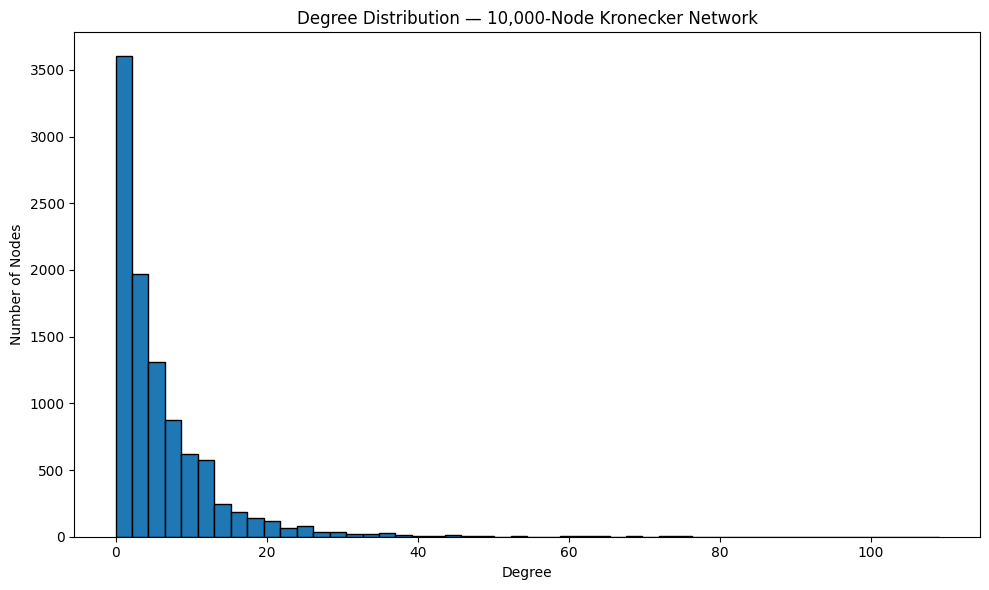

In [6]:
# Cell 6 — Degree distribution

degree_values = np.array([d for _, d in G.degree()])

print("Minimum degree:", degree_values.min())
print("Maximum degree:", degree_values.max())
print("Average degree:", degree_values.mean())
print("Median degree :", np.median(degree_values))

plt.figure(figsize=(10, 6))
plt.hist(degree_values, bins=50, edgecolor="black")
plt.title("Degree Distribution — 10,000-Node Kronecker Network")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "01_degree_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


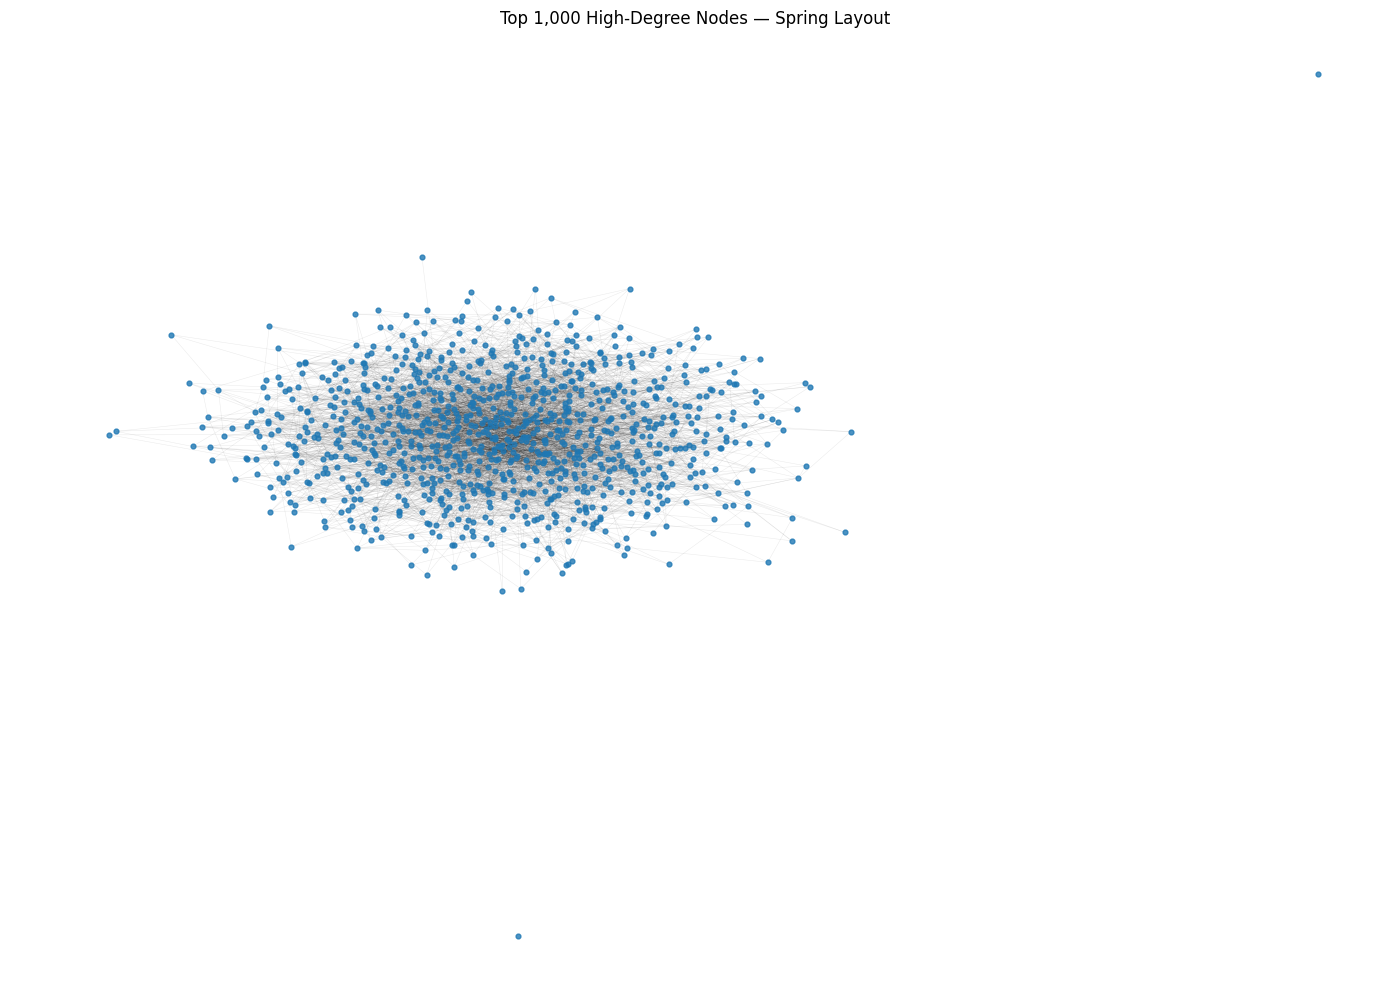

In [7]:
# Cell 7 — Spring layout of top 1,000 nodes by degree

TOP_N = 1000

top_nodes = [
    node for node, _ in
    sorted(G.degree(), key=lambda x: x[1], reverse=True)[:TOP_N]
]

G_top = G.subgraph(top_nodes).copy()

pos_spring = nx.spring_layout(
    G_top,
    seed=SEED,
    iterations=30,
    k=0.15
)

plt.figure(figsize=(14, 10))
nx.draw_networkx_edges(
    G_top, pos_spring,
    alpha=0.08, width=0.4
)
nx.draw_networkx_nodes(
    G_top, pos_spring,
    node_size=12, alpha=0.8
)

plt.title("Top 1,000 High-Degree Nodes — Spring Layout")
plt.axis("off")
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "02_top1000_spring.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


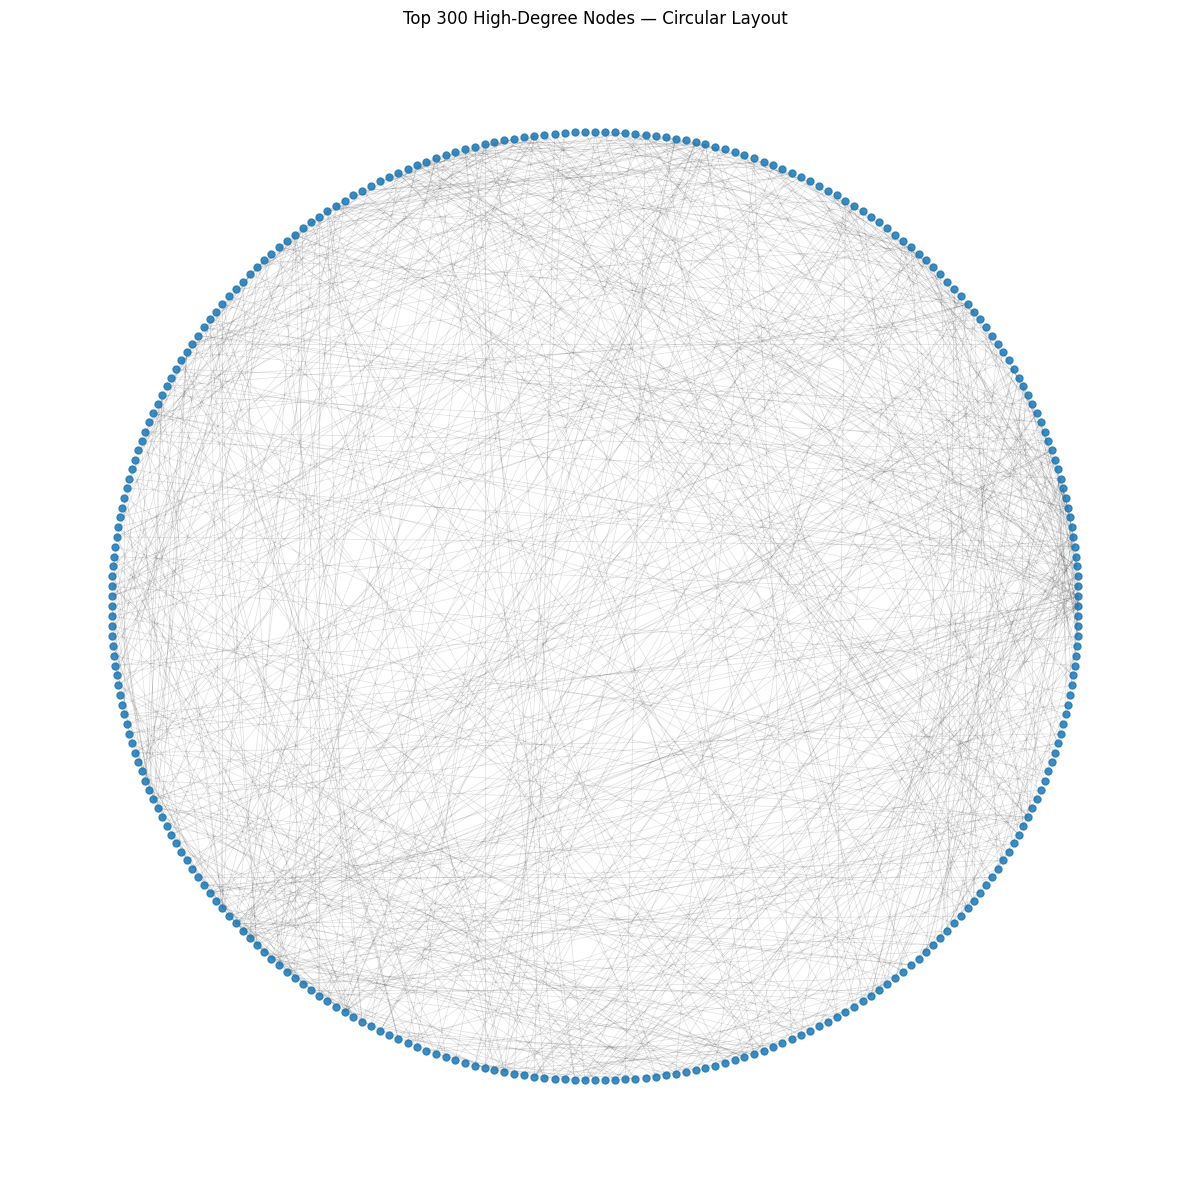

In [8]:
# Cell 8 — Circular layout of top 300 nodes

TOP_N_CIRCULAR = 300

top_300 = [
    node for node, _ in
    sorted(G.degree(), key=lambda x: x[1], reverse=True)[:TOP_N_CIRCULAR]
]

G_300 = G.subgraph(top_300).copy()
pos_circular = nx.circular_layout(G_300)

plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(
    G_300, pos_circular,
    alpha=0.12, width=0.5
)
nx.draw_networkx_nodes(
    G_300, pos_circular,
    node_size=25, alpha=0.85
)

plt.title("Top 300 High-Degree Nodes — Circular Layout")
plt.axis("off")
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "03_top300_circular.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


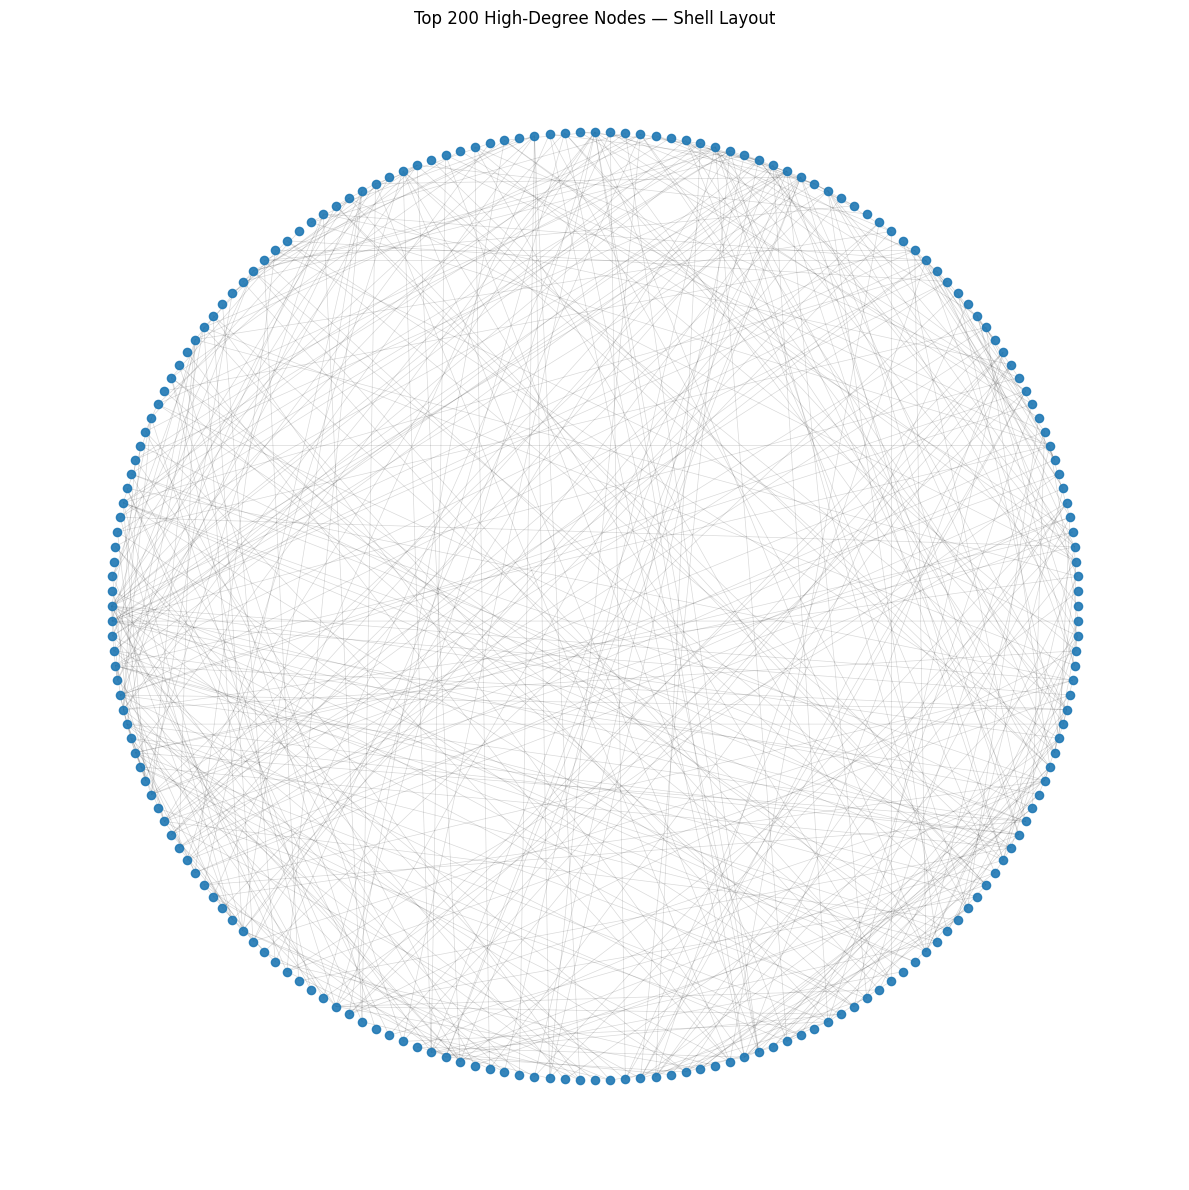

In [9]:
# Cell 9 — Shell layout of top 200 nodes

TOP_N_SHELL = 200

top_200 = [
    node for node, _ in
    sorted(G.degree(), key=lambda x: x[1], reverse=True)[:TOP_N_SHELL]
]

G_200 = G.subgraph(top_200).copy()
pos_shell = nx.shell_layout(G_200)

plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(
    G_200, pos_shell,
    alpha=0.15, width=0.5
)
nx.draw_networkx_nodes(
    G_200, pos_shell,
    node_size=35, alpha=0.9
)

plt.title("Top 200 High-Degree Nodes — Shell Layout")
plt.axis("off")
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "04_top200_shell.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


Number of connected components: 1072
Largest connected component nodes: 8913
Largest connected component edges: 29942


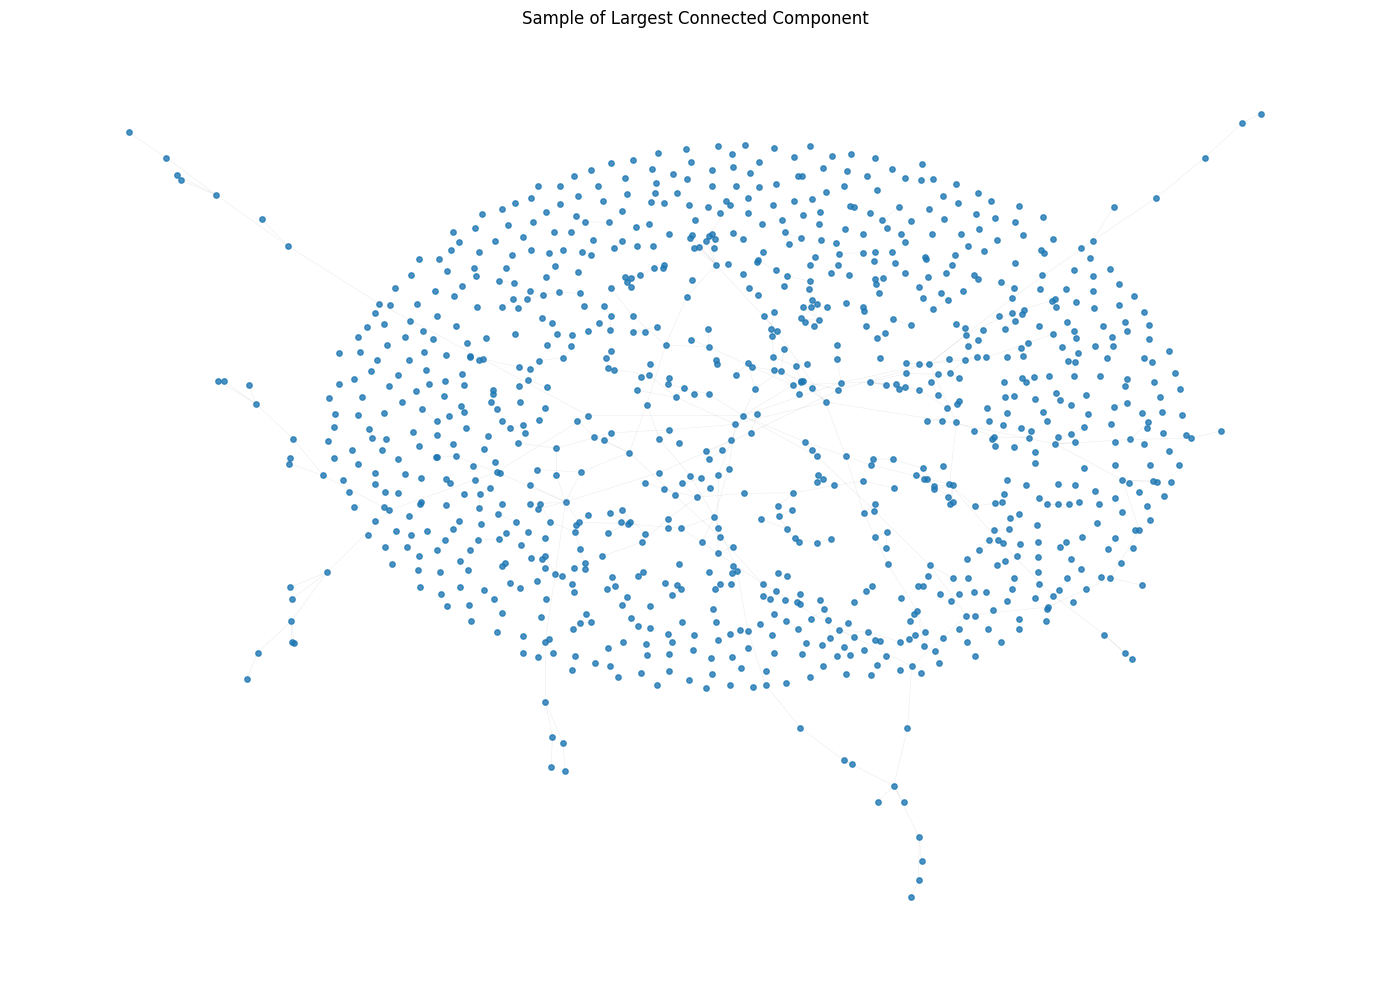

In [10]:
# Cell 10 — Largest connected component

components = sorted(
    nx.connected_components(G),
    key=len,
    reverse=True
)

G_lcc = G.subgraph(components[0]).copy()

print("Number of connected components:", len(components))
print("Largest connected component nodes:", G_lcc.number_of_nodes())
print("Largest connected component edges:", G_lcc.number_of_edges())

# Visual sample of LCC
sample_size = min(1000, G_lcc.number_of_nodes())
rng = np.random.default_rng(SEED)

sample_nodes = rng.choice(
    list(G_lcc.nodes()),
    size=sample_size,
    replace=False
)

G_lcc_sample = G_lcc.subgraph(sample_nodes).copy()

pos_lcc = nx.spring_layout(
    G_lcc_sample,
    seed=SEED,
    iterations=30,
    k=0.15
)

plt.figure(figsize=(14, 10))
nx.draw_networkx_edges(
    G_lcc_sample, pos_lcc,
    alpha=0.08, width=0.4
)
nx.draw_networkx_nodes(
    G_lcc_sample, pos_lcc,
    node_size=15, alpha=0.8
)

plt.title("Sample of Largest Connected Component")
plt.axis("off")
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "05_largest_connected_component.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# Part II-B — Network Insights

The following cells calculate the required NetworkX metrics.

**Important:** Radius and diameter are calculated on the largest connected component because shortest-path distance is not defined between nodes in different disconnected components.

For a 10,000-node network, exact all-node betweenness centrality can be very expensive. The notebook uses NetworkX's sampling approximation with 500 source nodes and explicitly records that methodological choice.


In [11]:
# Cell 11 — Average degree and density

number_of_nodes = G.number_of_nodes()
number_of_edges = G.number_of_edges()

average_degree = 2 * number_of_edges / number_of_nodes
density = nx.density(G)

print("Average Degree:", average_degree)
print("Graph Density :", density)


Average Degree: 5.9916
Graph Density : 0.0005992199219921992


In [12]:
# Cell 12 — Radius and diameter on largest connected component

print("Calculating radius and diameter on the largest connected component...")
print("LCC nodes:", G_lcc.number_of_nodes())

radius = nx.radius(G_lcc)
diameter = nx.diameter(G_lcc)

print("Radius  :", radius)
print("Diameter:", diameter)


Calculating radius and diameter on the largest connected component...
LCC nodes: 8913
Radius  : 6
Diameter: 10


In [13]:
# Cell 13 — Average clustering and node clustering coefficients

average_clustering = nx.average_clustering(G)
clustering_coefficients = nx.clustering(G)

clustering_df = pd.DataFrame(
    clustering_coefficients.items(),
    columns=["Node", "Clustering_Coefficient"]
).sort_values(
    "Clustering_Coefficient",
    ascending=False
)

print("Average Clustering Coefficient:", average_clustering)
print("\nTop 10 nodes by clustering coefficient:")
display(clustering_df.head(10))


Average Clustering Coefficient: 0.002244648297759135

Top 10 nodes by clustering coefficient:


,Node,Clustering_Coefficient
9227,9227,1.000000
8763,8763,1.000000
3327,3327,0.333333
5468,5468,0.333333
5347,5347,0.333333
7368,7368,0.333333
5045,5045,0.333333
8583,8583,0.333333
872,872,0.333333
7494,7494,0.333333


In [14]:
# Cell 14 — Degree table

degree_df = pd.DataFrame(
    G.degree(),
    columns=["Node", "Degree"]
).sort_values(
    "Degree",
    ascending=False
)

print("Top 20 nodes by degree:")
display(degree_df.head(20))


Top 20 nodes by degree:


,Node,Degree
0,0,109
1,1,76
512,512,75
4,4,74
32,32,72
2,2,70
256,256,69
2048,2048,69
64,64,65
128,128,65


In [15]:
# Cell 15 — Closeness centrality

print("Calculating closeness centrality on the largest connected component...")
start = time.time()

closeness = nx.closeness_centrality(G_lcc)

print("Completed in", round(time.time() - start, 2), "seconds")

closeness_df = pd.DataFrame(
    closeness.items(),
    columns=["Node", "Closeness_Centrality"]
).sort_values(
    "Closeness_Centrality",
    ascending=False
)

display(closeness_df.head(20))


Calculating closeness centrality on the largest connected component...
Completed in 124.73 seconds


,Node,Closeness_Centrality
0,0,0.320472
4,4,0.303429
32,32,0.303294
1,1,0.302707
2,2,0.301407
258,258,0.300340
3937,4096,0.299966
1991,2048,0.299805
128,128,0.299714
272,272,0.299080


In [16]:
# Cell 16 — Approximate betweenness centrality

# Exact betweenness centrality for 10,000 nodes may be expensive.
# k=500 samples 500 source nodes.

BETWEENNESS_SAMPLES = 500

print(
    f"Calculating approximate betweenness using "
    f"{BETWEENNESS_SAMPLES} sampled source nodes..."
)

start = time.time()

betweenness = nx.betweenness_centrality(
    G_lcc,
    k=BETWEENNESS_SAMPLES,
    normalized=True,
    seed=SEED
)

print("Completed in", round(time.time() - start, 2), "seconds")

betweenness_df = pd.DataFrame(
    betweenness.items(),
    columns=["Node", "Betweenness_Centrality"]
).sort_values(
    "Betweenness_Centrality",
    ascending=False
)

display(betweenness_df.head(20))


Calculating approximate betweenness using 500 sampled source nodes...
Completed in 27.81 seconds


,Node,Betweenness_Centrality
0,0,0.030171
3937,4096,0.020082
4,4,0.019969
511,512,0.015882
64,64,0.015207
256,256,0.014931
128,128,0.014141
2,2,0.013833
258,258,0.013810
16,16,0.013578


## Community Detection

Louvain community detection is used to partition the network into communities. The resulting partition is then evaluated using modularity.


In [17]:
# Cell 17 — Louvain community detection

print("Detecting communities using Louvain method...")

start = time.time()

communities = nx.community.louvain_communities(
    G,
    seed=SEED
)

print("Completed in", round(time.time() - start, 2), "seconds")
print("Number of communities:", len(communities))


Detecting communities using Louvain method...
Completed in 3.4 seconds
Number of communities: 1096


,Community_Rank,Number_of_Nodes
0,1,1143
1,2,1134
2,3,1065
3,4,1052
4,5,849
5,6,419
6,7,352
7,8,313
8,9,305
9,10,253


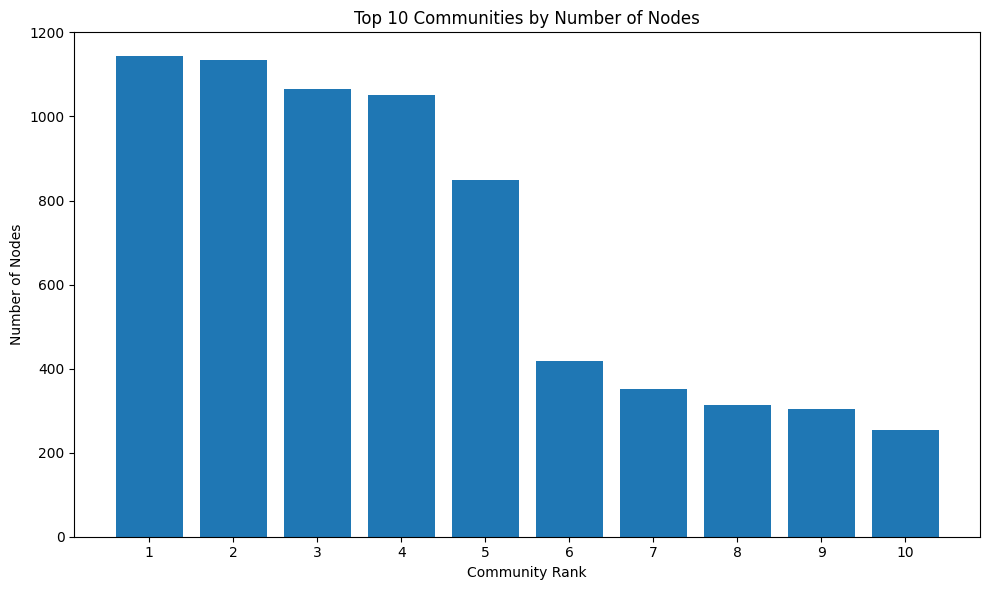

In [18]:
# Cell 18 — Community sizes

community_sizes = sorted(
    [len(c) for c in communities],
    reverse=True
)

community_size_df = pd.DataFrame({
    "Community_Rank": range(1, len(community_sizes) + 1),
    "Number_of_Nodes": community_sizes
})

display(community_size_df.head(20))

plt.figure(figsize=(10, 6))

top_10_communities = community_size_df.head(10)

plt.bar(
    top_10_communities["Community_Rank"].astype(str),
    top_10_communities["Number_of_Nodes"]
)

plt.title("Top 10 Communities by Number of Nodes")
plt.xlabel("Community Rank")
plt.ylabel("Number of Nodes")
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "06_community_sizes.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [19]:
# Cell 19 — Assign community IDs to nodes

community_map = {}

for community_id, community in enumerate(communities):
    for node in community:
        community_map[node] = community_id

nx.set_node_attributes(
    G,
    community_map,
    "community"
)

print("Community IDs assigned to", len(community_map), "nodes.")


Community IDs assigned to 10000 nodes.


In [20]:
# Cell 20 — Modularity

modularity = nx.community.modularity(
    G,
    communities
)

print("Modularity:", modularity)


Modularity: 0.35842029376320567


Largest community nodes: 1143
Largest community edges: 2153


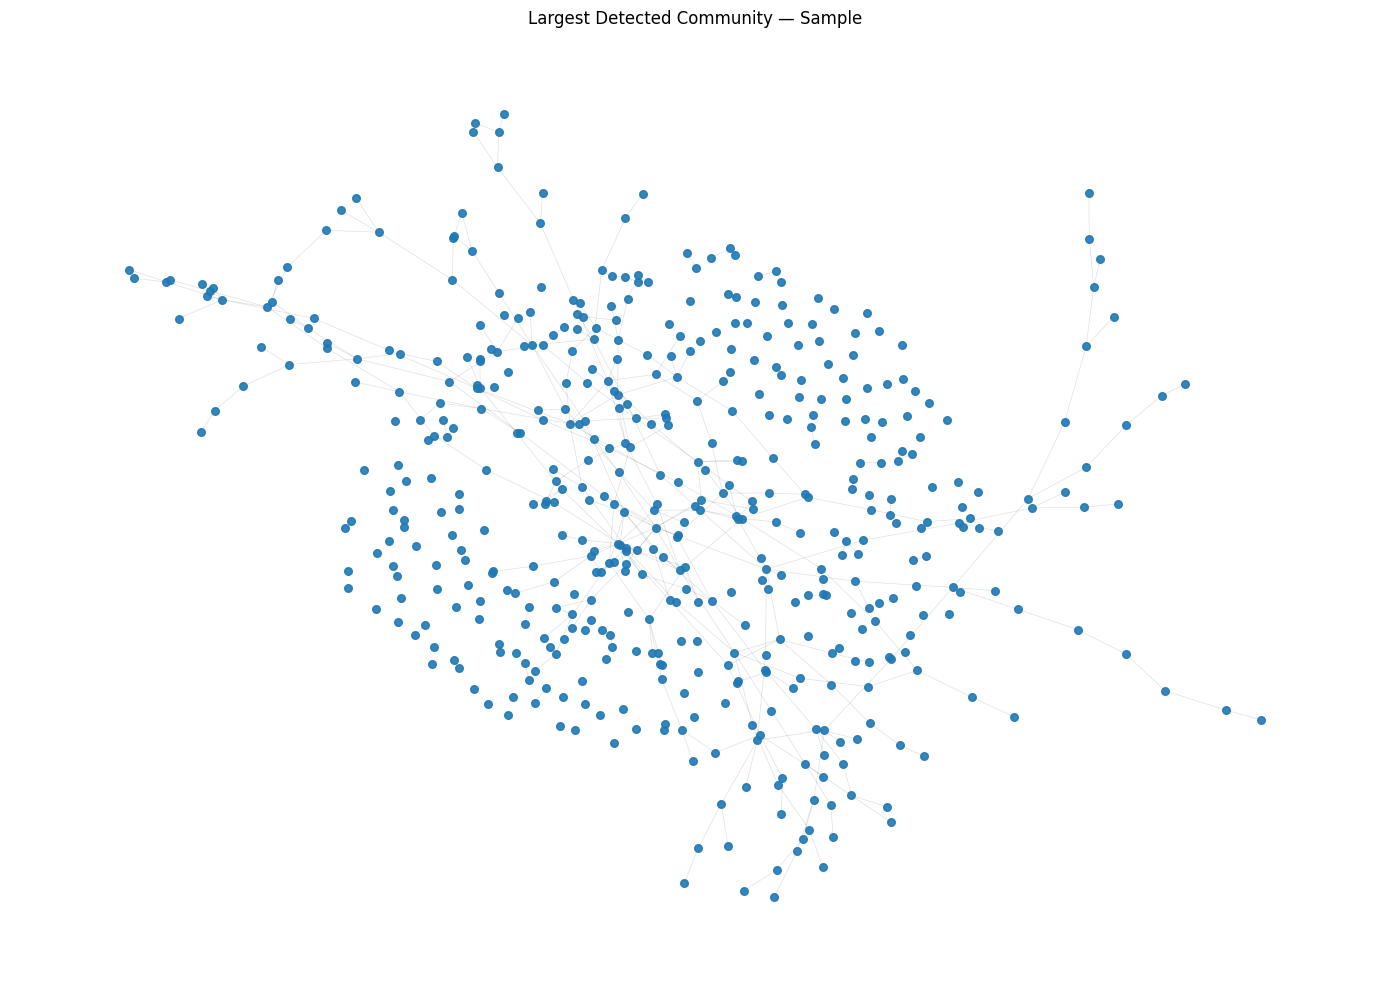

In [21]:
# Cell 21 — Largest community visualization

largest_community = max(
    communities,
    key=len
)

G_community = G.subgraph(largest_community).copy()

print("Largest community nodes:", G_community.number_of_nodes())
print("Largest community edges:", G_community.number_of_edges())

COMMUNITY_VIS_N = min(500, G_community.number_of_nodes())

rng = np.random.default_rng(SEED)

if G_community.number_of_nodes() > COMMUNITY_VIS_N:
    community_sample_nodes = rng.choice(
        list(G_community.nodes()),
        size=COMMUNITY_VIS_N,
        replace=False
    )
else:
    community_sample_nodes = list(G_community.nodes())

G_community_sample = G_community.subgraph(
    community_sample_nodes
).copy()

pos_community = nx.spring_layout(
    G_community_sample,
    seed=SEED,
    iterations=40,
    k=0.2
)

plt.figure(figsize=(14, 10))

nx.draw_networkx_edges(
    G_community_sample,
    pos_community,
    alpha=0.12,
    width=0.5
)

nx.draw_networkx_nodes(
    G_community_sample,
    pos_community,
    node_size=30,
    alpha=0.9
)

plt.title("Largest Detected Community — Sample")
plt.axis("off")
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "07_largest_community.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [22]:
# Cell 22 — Add analysis attributes to the graph

# Degree and clustering for all nodes
nx.set_node_attributes(
    G,
    dict(G.degree()),
    "degree"
)

nx.set_node_attributes(
    G,
    clustering_coefficients,
    "clustering_coefficient"
)

# Closeness and approximate betweenness are available for LCC.
# Nodes outside the LCC are left without those attributes.
nx.set_node_attributes(
    G,
    closeness,
    "closeness_centrality"
)

nx.set_node_attributes(
    G,
    betweenness,
    "betweenness_centrality"
)

# Community ID
nx.set_node_attributes(
    G,
    community_map,
    "community"
)

print("Node attributes added.")


Node attributes added.


In [23]:
# Cell 23 — Save enriched GEXF for Gephi

final_gexf_file = os.path.join(
    OUTPUT_DIR,
    f"GT_Assign_{PRN_NO}_Final.gexf"
)

nx.write_gexf(
    G,
    final_gexf_file
)

print("Enriched GEXF saved to:")
print(final_gexf_file)


Enriched GEXF saved to:
GT_Assign_Output/GT_Assign_YOUR_PRN_NO_Final.gexf


In [24]:
# Cell 24 — Final metrics table

metrics = {
    "Number of Nodes": G.number_of_nodes(),
    "Number of Edges": G.number_of_edges(),
    "Average Degree": average_degree,
    "Graph Density": density,
    "Average Clustering Coefficient": average_clustering,
    "Connected Components": len(components),
    "Largest Connected Component Nodes": G_lcc.number_of_nodes(),
    "Largest Connected Component Edges": G_lcc.number_of_edges(),
    "Radius (Largest Connected Component)": radius,
    "Diameter (Largest Connected Component)": diameter,
    "Number of Communities": len(communities),
    "Modularity": modularity,
    "Betweenness Method": f"Approximate; k={BETWEENNESS_SAMPLES}"
}

metrics_df = pd.DataFrame(
    list(metrics.items()),
    columns=["Metric", "Value"]
)

display(metrics_df)


,Metric,Value
0,Number of Nodes,10000
1,Number of Edges,29958
2,Average Degree,5.9916
3,Graph Density,0.000599
4,Average Clustering Coefficient,0.002245
5,Connected Components,1072
6,Largest Connected Component Nodes,8913
7,Largest Connected Component Edges,29942
8,Radius (Largest Connected Component),6
9,Diameter (Largest Connected Component),10


In [25]:
# Cell 25 — Export CSV result files

degree_df.to_csv(
    os.path.join(OUTPUT_DIR, "degree.csv"),
    index=False
)

clustering_df.to_csv(
    os.path.join(OUTPUT_DIR, "clustering_coefficients.csv"),
    index=False
)

closeness_df.to_csv(
    os.path.join(OUTPUT_DIR, "closeness_centrality.csv"),
    index=False
)

betweenness_df.to_csv(
    os.path.join(OUTPUT_DIR, "betweenness_centrality_approx.csv"),
    index=False
)

community_size_df.to_csv(
    os.path.join(OUTPUT_DIR, "community_sizes.csv"),
    index=False
)

metrics_df.to_csv(
    os.path.join(OUTPUT_DIR, "network_metrics.csv"),
    index=False
)

print("CSV result files exported.")


CSV result files exported.


In [26]:
# Cell 26 — Final summary for report

print("=" * 70)
print("FINAL NETWORK ANALYSIS SUMMARY")
print("=" * 70)

print(f"Nodes                         : {G.number_of_nodes():,}")
print(f"Edges                         : {G.number_of_edges():,}")
print(f"Average Degree                : {average_degree:.4f}")
print(f"Graph Density                 : {density:.8f}")
print(f"Average Clustering            : {average_clustering:.6f}")
print(f"Connected Components          : {len(components)}")
print(f"LCC Nodes                     : {G_lcc.number_of_nodes():,}")
print(f"LCC Edges                     : {G_lcc.number_of_edges():,}")
print(f"Radius (LCC)                  : {radius}")
print(f"Diameter (LCC)                : {diameter}")
print(f"Number of Communities         : {len(communities)}")
print(f"Modularity                    : {modularity:.6f}")
print(f"Betweenness Sampling          : k={BETWEENNESS_SAMPLES}")
print("=" * 70)

print("\nOutput directory:", OUTPUT_DIR)


FINAL NETWORK ANALYSIS SUMMARY
Nodes                         : 10,000
Edges                         : 29,958
Average Degree                : 5.9916
Graph Density                 : 0.00059922
Average Clustering            : 0.002245
Connected Components          : 1072
LCC Nodes                     : 8,913
LCC Edges                     : 29,942
Radius (LCC)                  : 6
Diameter (LCC)                : 10
Number of Communities         : 1096
Modularity                    : 0.358420
Betweenness Sampling          : k=500

Output directory: GT_Assign_Output


# Suggested Report Interpretation

Use your actual values from the final summary rather than inventing numbers.

### Meaningful Insights to discuss

1. **Degree:** Identify whether a small number of nodes have substantially higher degree than the majority. Such nodes can be described as highly connected or hub-like nodes.
2. **Clustering:** Explain whether neighboring nodes tend to form triangles/local groups.
3. **Centrality:** Compare the top degree, closeness and betweenness nodes. A node ranking highly in multiple measures can be interpreted as structurally important.
4. **Communities:** Report the number and size of detected communities and explain that communities represent groups with relatively dense internal connections.
5. **Modularity:** Use the calculated modularity to discuss the strength of the detected partition.
6. **Radius/Diameter:** Explain the shortest-path reachability of the largest connected component.
7. **Visualization:** Use the full-network GEXF in Gephi for the final 10,000-node visualization; use NetworkX subgraphs in the report where labels and structure can be interpreted clearly.

### Methodological note for the report

> “The network was generated synthetically using a stochastic Kronecker graph model with a 2×2 initiator matrix. The model generates node IDs through repeated bit-level Kronecker sampling. Exactly 10,000 nodes were retained in the final network. NetworkX was used for graph construction, visualization and structural analysis. Radius and diameter were calculated on the largest connected component, while betweenness centrality was approximated using 500 sampled source nodes because exact computation on a 10,000-node graph is computationally intensive.”
